<a href="https://colab.research.google.com/github/AlisaLeibova/ML-study/blob/main/Copy_of_HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any

In [2]:
raw_df = pd.read_csv("train.csv")

In [3]:

def split_train_val(df, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [4]:
target_col = "Exited"


input_cols = [col for col in raw_df.columns if col != target_col]


train_df, val_df = split_train_val(raw_df, target_col)

train_inputs, train_targets = separate_inputs_targets(
    train_df,
    input_cols,
    target_col
)

val_inputs, val_targets = separate_inputs_targets(
    val_df,
    input_cols,
    target_col
)
print("Train inputs:", train_inputs.shape)
print("Train targets:", train_targets.shape)
print("Validation inputs:", val_inputs.shape)
print("Validation targets:", val_targets.shape)

Train inputs: (12000, 13)
Train targets: (12000,)
Validation inputs: (3000, 13)
Validation targets: (3000,)


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [5]:
cat_cols = train_inputs.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    train_inputs[col] = train_inputs[col].astype("category")
    val_inputs[col] = pd.Categorical(val_inputs[col], categories=train_inputs[col].cat.categories)

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [6]:
!conda install -c conda-forge xgboost

/bin/bash: line 1: conda: command not found


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True,
    missing=np.nan,
    tree_method="hist",
    eval_metric="auc"
)

xgb_clf.fit(train_inputs, train_targets)

train_proba = xgb_clf.predict_proba(train_inputs)[:, 1]
val_proba = xgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_proba)
val_auc = roc_auc_score(val_targets, val_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9531
Validation AUROC: 0.9349


3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [8]:
!pip install hyperopt

In [9]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [10]:
import numpy as np
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

space = {
    "max_depth": hp.quniform("max_depth", 2, 6, 1),
    "n_estimators": hp.quniform("n_estimators", 30, 150, 10),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.3)),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.7, 1.0),
    "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
    "gamma": hp.uniform("gamma", 0.0, 5.0),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 1.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.5, 3.0),
}

def objective(params):
    params["max_depth"] = int(params["max_depth"])
    params["n_estimators"] = int(params["n_estimators"])
    params["min_child_weight"] = int(params["min_child_weight"])

    clf = XGBClassifier(
        **params,
        random_state=42,
        enable_categorical=True,
        missing=np.nan,
        tree_method="hist",
        eval_metric="auc",
    )
    clf.fit(train_inputs, train_targets)

    val_proba = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_proba)

    return {"loss": -val_auc, "status": STATUS_OK}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42),
)

best_params = space_eval(space, best)
print("Best params:", best_params)

100%|██████████| 20/20 [00:19<00:00,  1.02trial/s, best loss: -0.9378098635022979]
Best params: {'colsample_bytree': 0.9571948331620053, 'gamma': 4.250198863250397, 'learning_rate': 0.048038998810205125, 'max_depth': 4.0, 'min_child_weight': 9.0, 'n_estimators': 120.0, 'reg_alpha': 0.44194339835245333, 'reg_lambda': 0.9025602715437104, 'subsample': 0.9264182080794368}


In [11]:
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["min_child_weight"] = int(best_params["min_child_weight"])

final_clf = XGBClassifier(
    **best_params,
    random_state=42,
    enable_categorical=True,
    missing=np.nan,
    tree_method="hist",
    eval_metric="auc",
)

final_clf.fit(train_inputs, train_targets)

train_proba = final_clf.predict_proba(train_inputs)[:, 1]
val_proba = final_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_proba)
val_auc = roc_auc_score(val_targets, val_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9435
Validation AUROC: 0.9378


Модель стала трошки краща на validation даних

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [12]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

cat_cols = train_inputs.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    train_inputs[col] = train_inputs[col].astype("category")
    val_inputs[col] = pd.Categorical(val_inputs[col], categories=train_inputs[col].cat.categories)

cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_cols]

lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_clf.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes
)

train_proba = lgbm_clf.predict_proba(train_inputs)[:, 1]
val_proba = lgbm_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_proba)
val_auc = roc_auc_score(val_targets, val_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [13]:
import numpy as np
import pandas as pd
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

cat_cols = train_inputs.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    train_inputs[col] = train_inputs[col].astype("category")
    val_inputs[col] = pd.Categorical(val_inputs[col], categories=train_inputs[col].cat.categories)

cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_cols]

space = {
    "n_estimators": hp.quniform("n_estimators", 50, 200, 10),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.2)),
    "num_leaves": hp.quniform("num_leaves", 15, 63, 2),
    "max_depth": hp.quniform("max_depth", 3, 8, 1),
    "min_child_samples": hp.quniform("min_child_samples", 10, 50, 5),
    "subsample": hp.uniform("subsample", 0.7, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.7, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 1.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.0, 3.0),
}

def lgb_objective(params):
    params["n_estimators"] = int(params["n_estimators"])
    params["num_leaves"] = int(params["num_leaves"])
    params["max_depth"] = int(params["max_depth"])
    params["min_child_samples"] = int(params["min_child_samples"])

    clf = LGBMClassifier(
        **params,
        random_state=42
    )

    clf.fit(
        train_inputs,
        train_targets,
        categorical_feature=cat_feature_indexes
    )

    val_proba = clf.predict_proba(val_inputs)[:, 1]
    val_auc = roc_auc_score(val_targets, val_proba)

    return {"loss": -val_auc, "status": STATUS_OK}

trials = Trials()

best = fmin(
    fn=lgb_objective,
    space=space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials,
    rstate=np.random.default_rng(42),
)

best_params = space_eval(space, best)

best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["num_leaves"] = int(best_params["num_leaves"])
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_child_samples"] = int(best_params["min_child_samples"])

print("Best params:", best_params)

final_lgb_clf = LGBMClassifier(
    **best_params,
    random_state=42
)

final_lgb_clf.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes
)

train_proba = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_proba = final_lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_proba)
val_auc = roc_auc_score(val_targets, val_proba)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1826
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [14]:
test_df = pd.read_csv("test.csv")

In [15]:
test_inputs = test_df[input_cols].copy()

cat_cols = test_inputs.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    test_inputs[col] = pd.Categorical(test_inputs[col], categories=train_inputs[col].cat.categories)

test_proba = final_clf.predict_proba(test_inputs)[:, 1]

submission = pd.DataFrame({
    "id": test_df["id"],   # если в конкурсе другой столбец идентификатора, замени его
    "Exited": test_proba   # если нужен другой name target, замени его
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Exited
0,15000,0.149805
1,15001,0.024876
2,15002,0.067198
3,15003,0.521260
4,15004,0.043856


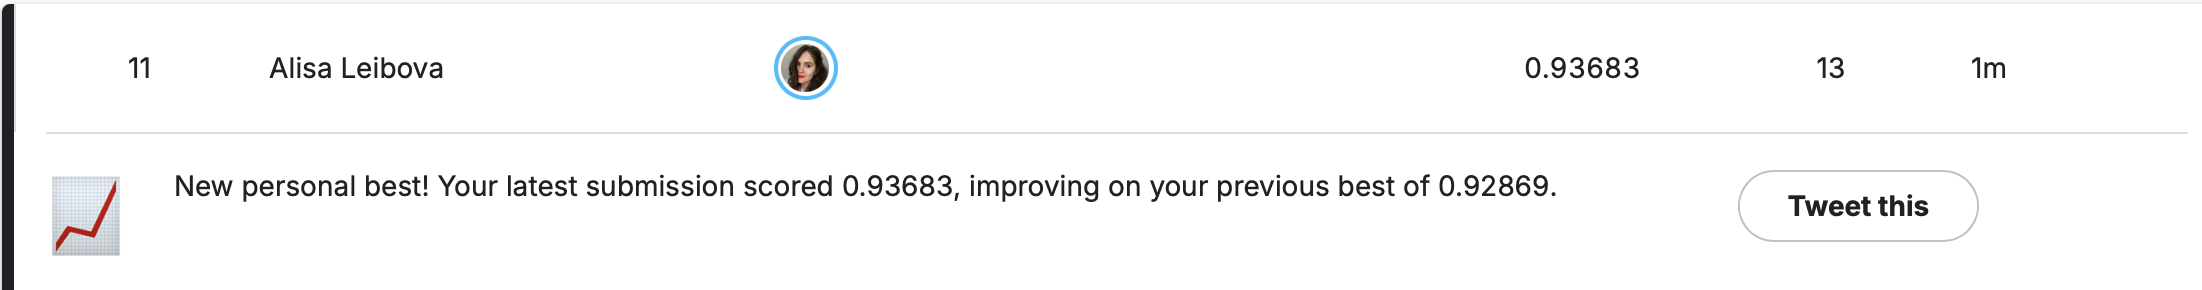